# Encoder Common Sense Question & Answering Model


## 1. Project Overview


## 2. Loading the Packages


In [ ]:
!pip install -q transformers datasets evaluate sentencepiece accelerate > /dev/null 2>&1

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import evaluate
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForMaskedLM

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## 3. Setting Up the Environment


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

MODEL_NAME = "FacebookAI/xlm-roberta-large"
MAX_LENGTH = 128
BATCH_SIZE = 4

print("Model name:", MODEL_NAME)
print("Maximum sequence length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)

Using device: cuda
Model name: FacebookAI/xlm-roberta-large
Maximum sequence length: 128
Batch size: 4


## 4. Loading the CommonsenseQA Dataset



In [ ]:
dataset = load_dataset("tau/commonsense_qa")
for split in dataset:
    print(f"{split}: {len(dataset[split])} examples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9741 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1221 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1140 [00:00<?, ? examples/s]

train: 9741 examples
validation: 1221 examples
test: 1140 examples


In [ ]:
train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

## 5. Exploring the Dataset Structure


In [ ]:
validation_dataset.column_names

['id', 'question', 'question_concept', 'choices', 'answerKey']

In [ ]:
example = validation_dataset[0]
example

{'id': '1afa02df02c908a558b4036e80242fac',
 'question': 'A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?',
 'question_concept': 'revolving door',
 'choices': {'label': ['A', 'B', 'C', 'D', 'E'],
  'text': ['bank', 'library', 'department store', 'mall', 'new york']},
 'answerKey': 'A'}

In [ ]:
print("Question:")
print(example["question"])
print()

print("Question concept:")
print(example["question_concept"])
print()

print("Choices:")
for label, text in zip(example["choices"]["label"], example["choices"]["text"]):
    print(f"{label}: {text}")
print()

print("Correct answer:")
print(example["answerKey"])

Question:
A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?

Question concept:
revolving door

Choices:
A: bank
B: library
C: department store
D: mall
E: new york

Correct answer:
A


## 6. Loading the Encoder Model and Tokenizer


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

XLMRobertaForMaskedLM LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMRobertaForMaskedLM(
  (lm_head): XLMRobertaLMHead(
    (dense): Linear(in_features=1024, out_features=1024, bias=True)
    (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (decoder): Linear(in_features=1024, out_features=250002, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
           

## 7. Preparing Multiple-Choice Inputs


In [ ]:
label_to_id = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
id_to_label = {v: k for k, v in label_to_id.items()}

In [ ]:
def prepare_answer_choices(example):
    question = example["question"]
    choice_labels = example["choices"]["label"]
    choice_texts = example["choices"]["text"]

    candidates = []
    for label, choice in zip(choice_labels, choice_texts):
        candidate_text = f"Question: {question} Answer: {choice}"
        candidates.append({
            "label": label,
            "choice_text": choice,
            "candidate_text": candidate_text
        })

    correct_label = example.get("answerKey")
    correct_id = label_to_id[correct_label] if correct_label is not None else None

    return {
        "question": question,
        "candidates": candidates,
        "correct_label": correct_label,
        "correct_id": correct_id
    }

prepared_example = prepare_answer_choices(validation_dataset[0])

print(f"Question: \n{prepared_example["question"]}")

for candidate in prepared_example["candidates"]:
    print(f"{candidate['label']}: {candidate['candidate_text']}")

print(f"Correct label:{prepared_example["correct_label"]}, Correct id: {prepared_example["correct_id"]}")

Question: 
A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
A: Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what? Answer: bank
B: Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what? Answer: library
C: Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what? Answer: department store
D: Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what? Answer: mall
E: Question: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what? Answer: new york
Correct label:A, Correct id: 0


## 8. Baseline Evaluation


In [ ]:
def build_candidate_text(question, answer):
    return f"Question: {question} Answer: {answer}"

In [ ]:
def compute_pll_score(question, answer, tokenizer, model, device, max_length=128):
    candidate_text = build_candidate_text(question, answer)

    encoding = tokenizer(
        candidate_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = encoding["input_ids"][0]
    attention_mask = encoding["attention_mask"][0]

    answer_tokens = tokenizer(answer, add_special_tokens=False)["input_ids"]

    input_ids_list = input_ids.tolist()

    def find_sublist(sequence, sublist):
        for i in range(len(sequence) - len(sublist) + 1):
            if sequence[i:i + len(sublist)] == sublist:
                return i
        return -1

    answer_start = find_sublist(input_ids_list, answer_tokens)

    if answer_start == -1:
        return None

    answer_positions = list(range(answer_start, answer_start + len(answer_tokens)))

    total_log_prob = 0.0

    for pos in answer_positions:
        masked_input_ids = input_ids.clone()
        original_token_id = masked_input_ids[pos].item()
        masked_input_ids[pos] = tokenizer.mask_token_id

        with torch.no_grad():
            outputs = model(
                input_ids=masked_input_ids.unsqueeze(0).to(device),
                attention_mask=attention_mask.unsqueeze(0).to(device)
            )

        logits = outputs.logits[0, pos]
        log_probs = F.log_softmax(logits, dim=-1)
        total_log_prob += log_probs[original_token_id].item()

    return total_log_prob

In [ ]:
def predict_example(example, tokenizer, model, device, max_length=128):
    question = example["question"]
    choice_labels = example["choices"]["label"]
    choice_texts = example["choices"]["text"]

    scores = []

    for label, choice in zip(choice_labels, choice_texts):
        score = compute_pll_score(
            question=question,
            answer=choice,
            tokenizer=tokenizer,
            model=model,
            device=device,
            max_length=max_length
        )
        scores.append({
            "label": label,
            "choice_text": choice,
            "score": score
        })

    valid_scores = [s for s in scores if s["score"] is not None]

    if len(valid_scores) == 0:
        return None

    best_candidate = max(valid_scores, key=lambda x: x["score"])

    return {
        "question": question,
        "scores": scores,
        "predicted_label": best_candidate["label"],
        "predicted_choice": best_candidate["choice_text"],
        "correct_label": example.get("answerKey")
    }

In [ ]:
test_prediction = predict_example(
    validation_dataset[0],
    tokenizer=tokenizer,
    model=model,
    device=device,
    max_length=MAX_LENGTH
)

print("Question:")
print(test_prediction["question"])

for item in test_prediction["scores"]:
    print(f"{item['label']}: {item['choice_text']}")
    print(f"Score: {item['score']}")

print("Predicted label:", test_prediction["predicted_label"])
print("Predicted choice:", test_prediction["predicted_choice"])
print("Correct label:", test_prediction["correct_label"])

Question:
A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
A: bank
Score: -12.657624244689941
B: library
Score: -3.260017815977335
C: department store
Score: -4.856821537017822
D: mall
Score: -14.602150917053223
E: new york
Score: -1.0277792997658253
Predicted label: E
Predicted choice: new york
Correct label: A


## 9. Running Baseline Inference


In [ ]:
validation_subset = validation_dataset.select(range(100))

predictions = []

for i, example in enumerate(validation_subset):
    result = predict_example(
        example,
        tokenizer=tokenizer,
        model=model,
        device=device,
        max_length=MAX_LENGTH
    )

    if result is not None:
        predictions.append({
            "index": i,
            "question": result["question"],
            "predicted_label": result["predicted_label"],
            "predicted_choice": result["predicted_choice"],
            "correct_label": result["correct_label"],
            "is_correct": result["predicted_label"] == result["correct_label"],
            "scores": result["scores"]
        })

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(validation_subset)} examples")

print("Number of predictions:", len(predictions))

results_df = pd.DataFrame([
    {
        "index": item["index"],
        "question": item["question"],
        "predicted_label": item["predicted_label"],
        "predicted_choice": item["predicted_choice"],
        "correct_label": item["correct_label"],
        "is_correct": item["is_correct"]
    }
    for item in predictions
])

results_df.head()
results_df.sample(5, random_state=seed)

Processed 10/100 examples
Processed 20/100 examples
Processed 30/100 examples
Processed 40/100 examples
Processed 50/100 examples
Processed 60/100 examples
Processed 70/100 examples
Processed 80/100 examples
Processed 90/100 examples
Processed 100/100 examples
Number of predictions: 100


,index,question,predicted_label,predicted_choice,correct_label,is_correct
83,83,Where can I put this penny to save for later?,B,wallet,A,False
53,53,"A child wants to play, what would they likely want?",D,be dismembered by a chainsaw,C,False
70,70,If you have to read a book that is very dry and long you may become what?,E,bored,E,True
45,45,What is the result of applying for job?,C,praise,E,False
44,44,James knew that he shouldn't have been buying beer for minors. He didn't even get paid for it. Why was this bad?,A,lose money,D,False


## 10. Computing Evaluation Metrics


In [ ]:
accuracy = results_df["is_correct"].mean()

print(f"Baseline accuracy: {accuracy}")
print(f"Baseline accuracy (%): {int(accuracy * 100)}%")

Baseline accuracy: 0.28
Baseline accuracy (%): 28%


In [ ]:
num_correct = results_df["is_correct"].sum()
num_total = len(results_df)
num_incorrect = num_total - num_correct

print("Number of correct predictions:", num_correct)
print("Number of incorrect predictions:", num_incorrect)
print("Total number of predictions:", num_total)

Number of correct predictions: 28
Number of incorrect predictions: 72
Total number of predictions: 100


In [ ]:
prediction_distribution = results_df["predicted_label"].value_counts().sort_index()
print("Prediction distribution:")
print(prediction_distribution)

Prediction distribution:
predicted_label
A    18
B    23
C    14
D    24
E    21
Name: count, dtype: int64


In [ ]:
true_distribution = results_df["correct_label"].value_counts().sort_index()
print("True label distribution:")
print(true_distribution)

True label distribution:
correct_label
A    17
B    20
C    17
D    23
E    23
Name: count, dtype: int64


## 11. Running Predictions over the Enitre Validation Set

In [ ]:
predictions_full = []

for i, example in enumerate(validation_dataset):
    result = predict_example(
        example,
        tokenizer=tokenizer,
        model=model,
        device=device,
        max_length=MAX_LENGTH
    )

    if result is not None:
        predictions_full.append({
            "index": i,
            "question": result["question"],
            "predicted_label": result["predicted_label"],
            "predicted_choice": result["predicted_choice"],
            "correct_label": result["correct_label"],
            "is_correct": result["predicted_label"] == result["correct_label"],
            "scores": result["scores"]
        })

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(test_dataset)} examples")

print("Number of predictions:", len(predictions_full))

results_full = pd.DataFrame([
    {
        "index": item["index"],
        "question": item["question"],
        "predicted_label": item["predicted_label"],
        "predicted_choice": item["predicted_choice"],
        "correct_label": item["correct_label"],
        "is_correct": item["is_correct"],
        "scores": item["scores"]
    }
    for item in predictions_full
])

results_full.head()
results_full.sample(5, random_state=seed)

Processed 100/1140 examples
Processed 200/1140 examples
Processed 300/1140 examples
Processed 400/1140 examples
Processed 500/1140 examples
Processed 600/1140 examples
Processed 700/1140 examples
Processed 800/1140 examples
Processed 900/1140 examples
Processed 1000/1140 examples
Processed 1100/1140 examples
Processed 1200/1140 examples
Number of predictions: 1221


,index,question,predicted_label,predicted_choice,correct_label,is_correct,scores
542,542,"The man took paperwork to other people to consult over it, where was he heading?",A,desk,B,False,"[{'label': 'A', 'choice_text': 'desk', 'score': -7.113499879837036}, {'label': 'B', 'choice_text': 'meeting', 'score': -11.764400482177734}, {'label': 'C', 'choice_text': 'office', 'score': -11.066169738769531}, {'label': 'D', 'choice_text': 'table', 'score': -13.44918441772461}, {'label': 'E', 'choice_text': 'work', 'score': -9.6043701171875}]"
259,259,"If a person is working a lot, what are they likely trying to earn?",C,creativity,A,False,"[{'label': 'A', 'choice_text': 'much money', 'score': -9.98343300819397}, {'label': 'B', 'choice_text': 'own house', 'score': -10.307258129119873}, {'label': 'C', 'choice_text': 'creativity', 'score': -0.434936511331216}, {'label': 'D', 'choice_text': 'new car', 'score': -9.74977159500122}, {'label': 'E', 'choice_text': 'caregiver', 'score': -6.4843666553497314}]"
43,43,Where can you put a picture frame when it's not hung vertically?,B,wall,E,False,"[{'label': 'A', 'choice_text': 'art show', 'score': -17.942584991455078}, {'label': 'B', 'choice_text': 'wall', 'score': -10.840883255004883}, {'label': 'C', 'choice_text': 'newspaper', 'score': -14.925931930541992}, {'label': 'D', 'choice_text': 'car', 'score': -13.983064651489258}, {'label': 'E', 'choice_text': 'table', 'score': -12.739057540893555}]"
1011,1011,"He had no issue committing perjury, he had a what that he would get away with it?",B,go to jail,A,False,"[{'label': 'A', 'choice_text': 'confidence', 'score': -14.705390930175781}, {'label': 'B', 'choice_text': 'go to jail', 'score': -1.9827739575121086}, {'label': 'C', 'choice_text': 'telling lies', 'score': -12.428542578592896}, {'label': 'D', 'choice_text': 'lying', 'score': -4.328295111656189}, {'label': 'E', 'choice_text': 'manual', 'score': -16.75192642211914}]"
754,754,"The boat passenger was explaining his fear of blowfish, but the captain figured he meant piranhas since they were on a river in the what?",C,atlantic ocean,E,False,"[{'label': 'A', 'choice_text': 'cuba', 'score': -17.52022933959961}, {'label': 'B', 'choice_text': 'styx', 'score': -17.128077030181885}, {'label': 'C', 'choice_text': 'atlantic ocean', 'score': -3.1000297121936455}, {'label': 'D', 'choice_text': 'france', 'score': -15.444091320037842}, {'label': 'E', 'choice_text': 'jungle', 'score': -4.455608058720827}]"


## 12. Figures


In [ ]:
accuracy = results_full["is_correct"].mean()

print(f"Baseline accuracy: {accuracy}")
print(f"Baseline accuracy (%): {int(accuracy * 100)}%")

Baseline accuracy: 0.2833742833742834
Baseline accuracy (%): 28%


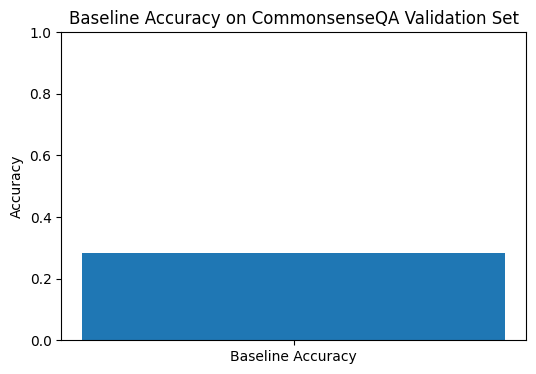

Baseline accuracy: 0.28
Baseline accuracy (%): 28.34%


In [ ]:
accuracy = results_full["is_correct"].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Baseline Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Baseline Accuracy on CommonsenseQA Validation Set")
plt.show()

print(f"Baseline accuracy: {accuracy:.2f}")
print(f"Baseline accuracy (%): {accuracy * 100:.2f}%")

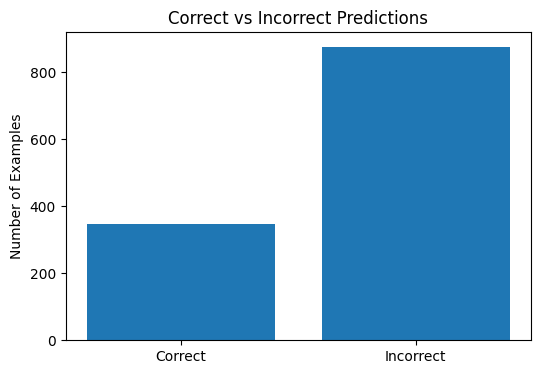

In [ ]:
correct_count = results_full["is_correct"].sum()
incorrect_count = len(results_full) - correct_count

plt.figure(figsize=(6, 4))
plt.bar(["Correct", "Incorrect"], [correct_count, incorrect_count])
plt.ylabel("Number of Examples")
plt.title("Correct vs Incorrect Predictions")
plt.show()

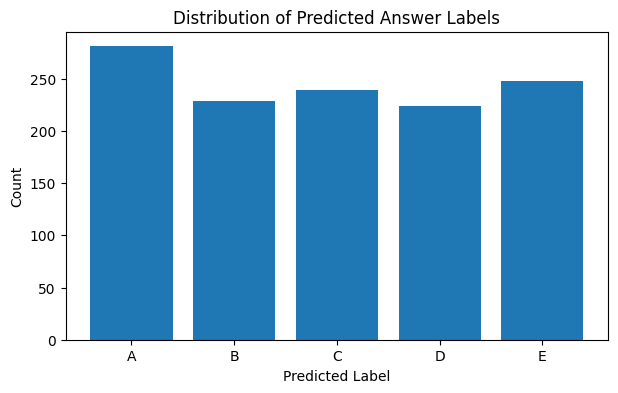

predicted_label
A    281
B    229
C    239
D    224
E    248
Name: count, dtype: int64


In [ ]:
pred_dist = results_full["predicted_label"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(pred_dist.index, pred_dist.values)
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.title("Distribution of Predicted Answer Labels")
plt.show()

print(pred_dist)

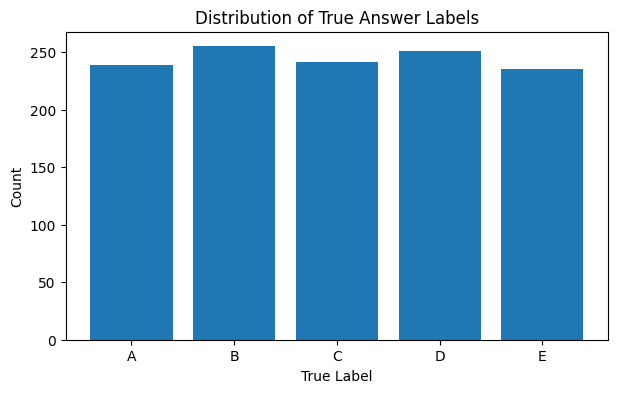

correct_label
A    239
B    255
C    241
D    251
E    235
Name: count, dtype: int64


In [ ]:
true_dist = results_full["correct_label"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(true_dist.index, true_dist.values)
plt.xlabel("True Label")
plt.ylabel("Count")
plt.title("Distribution of True Answer Labels")
plt.show()

print(true_dist)

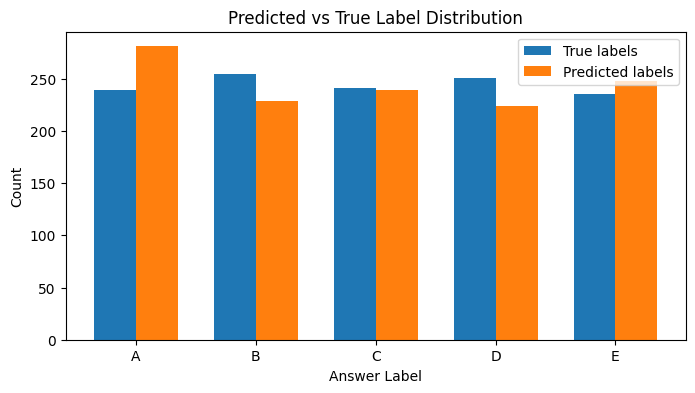

In [ ]:
labels = sorted(set(results_full["correct_label"]).union(set(results_full["predicted_label"])))
pred_values = [pred_dist.get(label, 0) for label in labels]
true_values = [true_dist.get(label, 0) for label in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, true_values, width, label="True labels")
plt.bar(x + width/2, pred_values, width, label="Predicted labels")
plt.xticks(x, labels)
plt.xlabel("Answer Label")
plt.ylabel("Count")
plt.title("Predicted vs True Label Distribution")
plt.legend()
plt.show()

In [ ]:
most_confident_correct = results_full[results_full["is_correct"]].sort_values("score_gap", ascending=False)
most_confident_incorrect = results_full[~results_full["is_correct"]].sort_values("score_gap", ascending=False)

print("Most confident correct predictions:")
display(most_confident_correct[["question", "predicted_label", "predicted_choice", "correct_label", "score_gap"]].head(10))

print("Most confident incorrect predictions:")
display(most_confident_incorrect[["question", "predicted_label", "predicted_choice", "correct_label", "score_gap"]].head(10))

Most confident correct predictions:


,question,predicted_label,predicted_choice,correct_label,score_gap
92,"Anybody could be hired in the kitchen, what was needed of them?",D,wash dishes,D,13.896170
774,"They dealt with combustible mixtures in their experiments, this is why they kept a fire extinguisher where?",B,chemistry lab,B,13.265441
583,Athletes soak in hot tubs to relieve what after playing baseball?,E,sore muscles,E,12.289049
781,"The business man was promoted recently, to celebrate he went where to buy an expensive wristwatch?",B,jewelry store,B,12.260207
195,"Alabama is full of different people, but they are all citizens of what?",A,united states,A,11.407768
25,When wildlife reproduce we often refer to what comes out as what?,D,offspring,D,10.746858
792,What rubber toy filled with helium will make a child happy?,D,balloon,D,10.541686
13,Aside from water and nourishment what does your dog need?,D,lots of attention,D,9.948880
824,"If one needed the bathroom they needed a key, to get it they had to also buy something from the what?",B,convenience store,B,9.942707
897,"She loved spending money at the thrift store on knickknacks, this resulted in a lot of what on every shelf in her house?",B,clutter,B,9.848672


Most confident incorrect predictions:


,question,predicted_label,predicted_choice,correct_label,score_gap
912,"If a fried egg was runny and there was no toast to sop it up, after the meal there'd be a messy what?",E,bird's nest,C,13.008632
906,Human beings learn about current events from what print item?,E,dictionary,C,12.798854
899,"If a person is using a computer to talk to their granddaughter, what might the computer cause for them?",E,headache,C,12.325312
236,"A car was hailed to chauffeur someone to the opera house, where was it heading?",E,east,A,11.716495
860,Why would a small dog pant if it's hot outside?,A,outside,C,11.542249
248,"The painter started to edge the room with tape, he always took extra care to make the lines clean and crisp when working with an what?",A,triangle,E,11.288671
159,"I couldn't find anybody who recalled the event, what were they adroit at doing?",C,wash dishes,E,11.228260
1208,Where would you find many varieties of plants including a rosebush?,C,backyard,E,11.192704
486,"They had a theory of what they could do in t he big game, so over and over they would what?",E,practise,B,11.138867
381,"The car's steering seem quite loose, but he still considered purchasing it because he needed something small and what?",A,sturdy,D,11.105284
